<a href="https://colab.research.google.com/github/Sank3t-Pand3y/Building_Advanced_Transformer_Using_KERAS./blob/main/Building_Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step-by-Step Instructions:

#### Step 1: Data Preprocessing

This exercise prepares the MNIST dataset for training by normalizing the pixel values and flattening the images. Normalization helps in faster convergence during training, and flattening is required because the input layer of our autoencoder expects a one-dimensional vector.


In [1]:
import numpy as np
from tensorflow.keras.datasets import mnist

# Load the dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize the pixel values
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten the images
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In the above code:
- Use Keras to load the MNIST dataset.
- Normalize the image pixel values to the range [0, 1].
- Flatten the 28x28 images to a 784-dimensional vector to reshape the data.


#### Step 2: Building the Autoencoder Model

This exercise involves building an autoencoder with an encoder that compresses the input to 32 dimensions and a decoder that reconstructs the input from these 32 dimensions. The model is compiled with the Adam optimizer and binary crossentropy loss.


In [2]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Encoder
input_layer = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_layer)

# Bottleneck
bottleneck = Dense(32, activation='relu')(encoded)

# Decoder
decoded = Dense(64, activation='relu')(bottleneck)
output_layer = Dense(784, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder = Model(input_layer, output_layer)

# Compile the model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Summary of the model
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,392 (411.69 KB)

 Trainable params: 105,392 (411.69 KB)

 Non-trainable params: 0 (0.00 B)

In the above code:

**1. Define the Encoder:**
- Create an input layer with 784 neurons.
- Add a Dense layer with 64 neurons and ReLU activation.

**2. Define the Bottleneck:**
- Add a Dense layer with 32 neurons and ReLU activation.

**3. Define the Decoder:**
- Add a Dense layer with 64 neurons and ReLU activation.
- Add an output layer with 784 neurons and sigmoid activation.

**4. Compile the Model:**
- Use the Adam optimizer and binary crossentropy loss.  


#### Step 3: Training the Autoencoder

In this exercise, the autoencoder is trained to reconstruct the MNIST images. The training data is both the input and the target, as the autoencoder learns to map the input to itself.


In [3]:
autoencoder.fit(
    x_train, x_train,
    epochs=25,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.3631 - val_loss: 0.1760
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1683 - val_loss: 0.1449
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1416 - val_loss: 0.1276
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1264 - val_loss: 0.1191
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1190 - val_loss: 0.1142
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1143 - val_loss: 0.1094
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1103 - val_loss: 0.1063
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1074 - val_loss: 0.1042
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1051 - val_loss: 0.1022
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1033 - val_loss: 0.1007
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1018 - val_loss: 0.0993
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In the above code:
- Use the `fit` method to train the model on the training data.
- Set the number of epochs to 25 and the batch size to 256..
- Use the test data for validation.


#### Step 4: Evaluating the Autoencoder

This exercise evaluates the autoencoder by reconstructing the test images and comparing them to the original images. Visualization helps in understanding how well the autoencoder has learned to reconstruct the input data.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


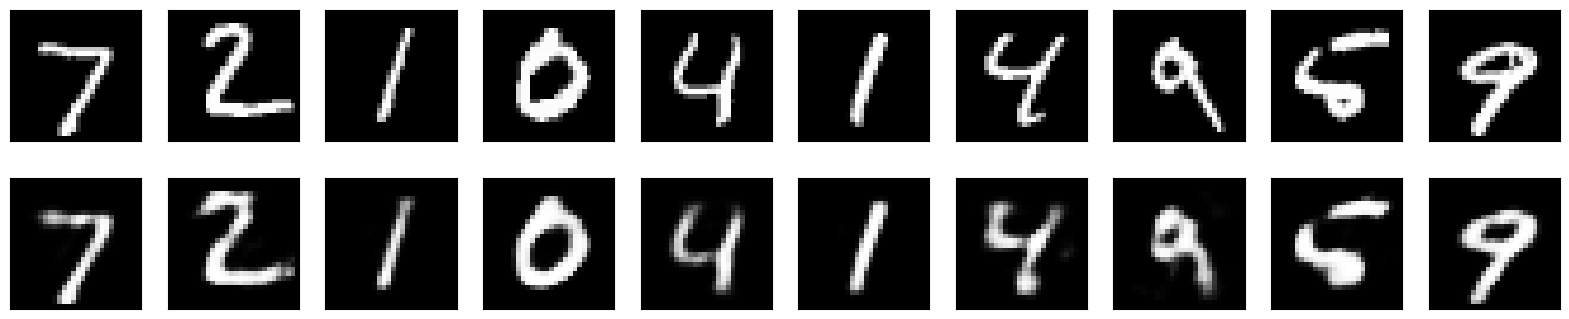

In [4]:
import matplotlib.pyplot as plt

## Predict the test data
reconstructed = autoencoder.predict(x_test)

## Visualize the results
n = 10 # Number of digits to display
plt.figure(figsize=(20,4))

for i in range(n):
  ## Display original
  ax = plt.subplot(2, n, i+1)
  plt.imshow(x_test[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  ## Display reconstruction
  ax = plt.subplot(2, n, i+1+n)
  plt.imshow(reconstructed[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)


plt.show()

In the above code:

**1. Reconstruct Images:**
- Use the autoencoder to predict the test data.
- Compare the original test images with the reconstructed images.

**2. Visualize the Results:**
- Plot a few examples of original and reconstructed images side by side.


#### Step 5: Fine-Tuning the Autoencoder

Fine-tuning the autoencoder by unfreezing some layers can help in improving its performance. In this exercise, you unfreeze the last four layers and train the model again for a few more epochs.


In [5]:
## Freeze all the layers of the autoencoder

for layer in autoencoder.layers:
  layer.trainable = False



In [6]:
## Check trainable status of each layer
for i, layer in enumerate(autoencoder.layers):
  print(f"Layer {i}: {layer.name}, Trainable = {layer.trainable}")


Layer 0: input_layer, Trainable = False
Layer 1: dense, Trainable = False
Layer 2: dense_1, Trainable = False
Layer 3: dense_2, Trainable = False
Layer 4: dense_3, Trainable = False


In [7]:
## Unfreeze the top layers of the encoder
for layer in autoencoder.layers[-4:]:
  layer.trainable = True


## Compile the model again
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

## Train the model again
autoencoder.fit(x_train, x_train, epochs=10, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0943 - val_loss: 0.0919
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0928 - val_loss: 0.0918
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0928 - val_loss: 0.0917
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0926 - val_loss: 0.0917
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0926 - val_loss: 0.0915
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0925 - val_loss: 0.0912
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0923 - val_loss: 0.0913
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0921 - val_loss: 0.0909
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0917 - val_loss: 0.0909
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0916 - val_loss: 0.0906


In the above code:

**1. Freeze all the Encoder Layers:**
- Freeze all the layers of the encoder.

**2. Check the Status:**
- Checking the trainable status of each layer.

**3. Unfreeze the Encoder Layers:**
- Unfreeze the last four layers of the encoder.

**4. Compile and Train the Model:**
- Recompile the model.
- Train the model again for 10 epochs with the same training and validation data.


#### Step 6: Denoising Images with Autoencoder

In this exercise, you add random noise to the dataset and train the autoencoder to denoise the images. The autoencoder learns to reconstruct the original images from the noisy input, which can be visualized by comparing the noisy, denoised, and original images.


Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.2179 - val_loss: 0.1439
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.1424 - val_loss: 0.1341
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1342 - val_loss: 0.1299
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1303 - val_loss: 0.1278
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1284 - val_loss: 0.1260
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.1269 - val_loss: 0.1252
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1258 - val_loss: 0.1243
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1251 - val_loss: 0.1240
Epoch 9/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1245 - val_loss: 0.1235
Epoch 10/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1243 - val_loss: 0.1231
Epoch 11/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1238 - val_loss: 0.1228
Epoch 12/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 

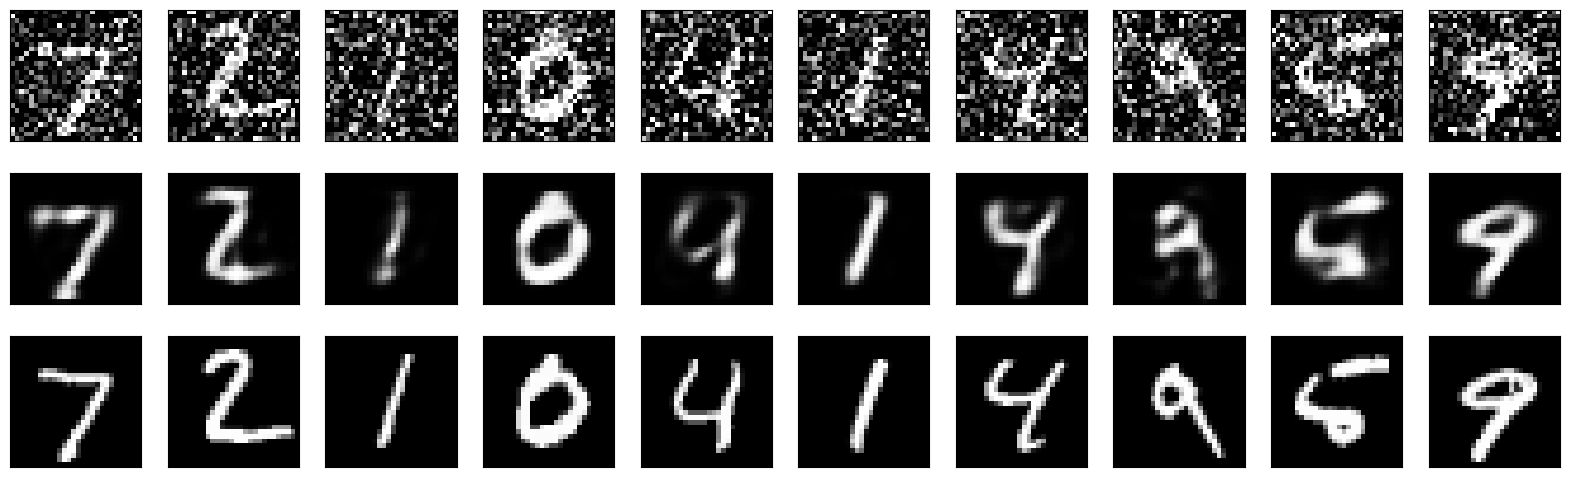

In [8]:
import numpy as np
import matplotlib.pyplot as plt

## Add noise to the data
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

## Train the autoencoder with noisy data
autoencoder.fit(x_train_noisy, x_train, epochs=20, batch_size=512, shuffle=True, validation_data=(x_test_noisy, x_test))


## Denoise the test images
reconstructed_noisy = autoencoder.predict(x_test_noisy)

## Visualize the results
n = 10 ## Number of digits to display
plt.figure(figsize=(20,6))
for i in range(n):
  # Display noisy images
  ax = plt.subplot(3, n, i+1)
  plt.imshow(x_test_noisy[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  ## Display denoised image
  ax = plt.subplot(3, n, i+1+n)
  plt.imshow(reconstructed_noisy[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  ## Display the original images
  ax = plt.subplot(3, n, i+1+2*n)
  plt.imshow(x_test[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

plt.show()

In the above code:

**1. Add noise to the data:**
- Add random noise to the training and test data.
- Train the Autoencoder with noisy data:
-Train the autoencoder using the noisy images as input and the original images as target.

**2. Evaluate the denoising performance:**
- Use the autoencoder to denoise the test images.
- Compare the noisy, denoised, and original images.


## Practice Exercises:

### Exercise 1: Exploring Different Bottleneck Sizes

#### Objective:

To understand the impact of different bottleneck sizes on the performance of the autoencoder.

#### Instructions:

**1. Define new models with different bottleneck sizes:**
- Create three new autoencoder models, each with a different bottleneck size (e.g., 16, 32, and 64 neurons).
- Use the same encoder and decoder architecture as in the main lab but change the number of neurons in the bottleneck layer.

**2. Train the models:**
- Train each model on the MNIST dataset for 50 epochs with a batch size of 256.
- Use the same preprocessing steps as in the main lab.

**3. Evaluate and Compare the Models:**
- Evaluate the performance of each model on the test data.
- Compare the reconstruction loss of the models to understand how the bottleneck size affects the autoencoder's ability to reconstruct the input data.


In [9]:
## Define and train three different autoencoders with varying bottleneck sizes

bottleneck_sizes = [16, 32, 64]
autoencoders = []

for size in bottleneck_sizes:
    ## Encoder
    input_layer = Input(shape=(784,))
    encoded = Dense(64, activation='relu')(input_layer)
    bottleneck = Dense(size, activation='relu')(encoded)

    ## Decoder
    decoded = Dense(64, activation='relu')(bottleneck)
    output_layer = Dense(784, activation='sigmoid')(decoded)

    ## Autoencoder model
    autoencoder = Model(input_layer, output_layer)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    autoencoder.fit(
        x_train,
        x_train,
        epochs=20,
        batch_size = 256,
        shuffle = True,
        validation_data = (x_test, x_test)
    )
    autoencoders.append(autoencoder)

## Evaluate and compare the model
for i, size in enumerate(bottleneck_sizes):
    loss = autoencoders[i].evaluate(x_test, x_test)
    print(f'Bottleneck size {size} - Test loss:{loss}')

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.3720 - val_loss: 0.1907
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1819 - val_loss: 0.1576
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1540 - val_loss: 0.1405
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.1387 - val_loss: 0.1312
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1310 - val_loss: 0.1254
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1262 - val_loss: 0.1224
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1233 - val_loss: 0.1206
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1216 - val_loss: 0.1191
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1206 - val_loss: 0.1177
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1189 - val_loss: 0.1165
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1178 - val_loss: 0.1147
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

### Exercise 2 - Adding Regularization to the Autoencoder

#### Objective:

To explore the effect of regularization on the performance of the autoencoder.

#### Instructions:

**1. Modify the model:**
- Add L2 regularization to the Dense layers in both the encoder and decoder parts of the autoencoder.

**2. Train the model:**
- Train the modified autoencoder on the MNIST dataset for 50 epochs with a batch size of 256.

**3. Evaluate and compare:**
- Evaluate the performance of the regularized autoencoder and compare it with the non-regularized version.


In [11]:
from tensorflow.keras.regularizers import l2

## Encoder with l2 regularization
input_layer = Input(shape=(784,))
encoded = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(input_layer)
bottleneck = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(encoded)

## Decoder with l2 regularization
decoded = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(bottleneck)
output_layer = Dense(784, activation='sigmoid', kernel_regularizer=l2(0.01))(decoded)

## Autoencoder model with l2 regularization
autoencoder_regularized = Model(input_layer, output_layer)
autoencoder_regularized.compile(optimizer='adam', loss='binary_crossentropy')

## Train the model
autoencoder_regularized.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data =(x_test,x_test))

## Evaluate the model
loss = autoencoder_regularized.evaluate(x_test, x_test)
print(f"Regularized_Autoencoder - Test loss : {loss}")

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 1.8116 - val_loss: 0.4419
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.4235 - val_loss: 0.3950
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.3919 - val_loss: 0.3799
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.3775 - val_loss: 0.3673
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3644 - val_loss: 0.3552
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3525 - val_loss: 0.3451
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.3431 - val_loss: 0.3364
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3350 - val_loss: 0.3298
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3287 - val_loss: 0.3235
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3221 - val_loss: 0.3181
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.3170 - val_loss: 0.3133
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

### Exercise 3 - Visualizing Intermediate Representations

#### Objective:

To visualize and understand the intermediate representations (encoded features) learned by the autoencoder.

#### Instructions:

**1. Extract Encoder Part:**
- Extract the encoder part of the trained autoencoder to create a separate model that outputs the encoded features.

**2. Visualize Encoded Features:**
- Use the encoder model to transform the test data into the encoded space.
- Plot the encoded features using a scatter plot for the first two dimensions of the encoded space.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


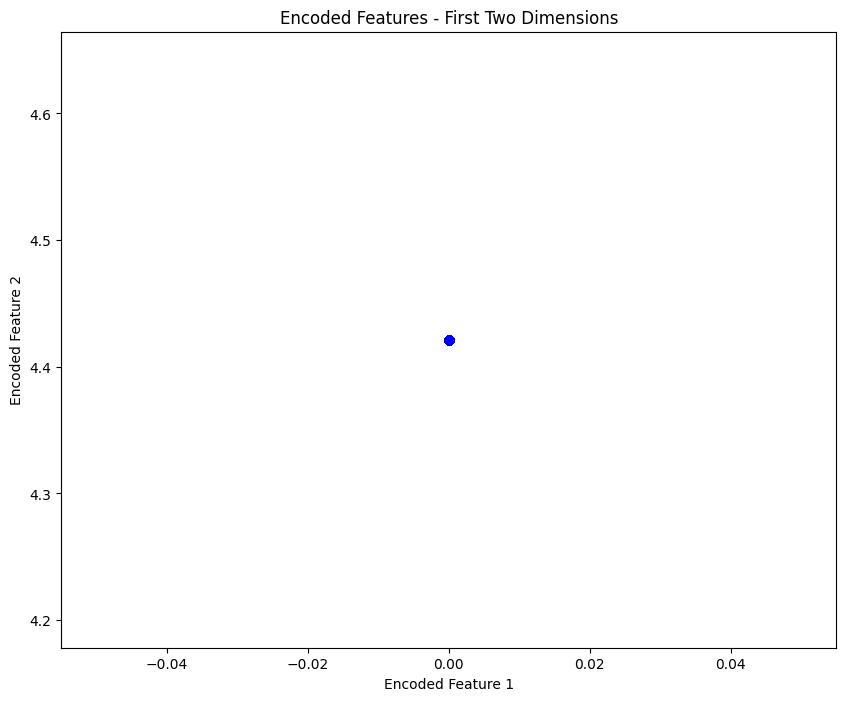

In [12]:
import matplotlib.pyplot as plt

## Extract the encoder part of the autoencoder
encoder_model = Model(input_layer, bottleneck)

## Encode the test data
encoded_imgs = encoder_model.predict(x_test)

## Visualize the first two dimensions of the encoded features
plt.figure(figsize=(10,8))
plt.scatter(encoded_imgs[:,0], encoded_imgs[:,1], c= 'blue', alpha=0.5)
plt.title("Encoded Features - First Two Dimensions")
plt.xlabel("Encoded Feature 1")
plt.ylabel("Encoded Feature 2")
plt.show()